# Exploratory Data Analysis

This notebook explores the San Diego police stops dataset (2014-2017) merged with the Social Vulnerability Index (SVI) by police service area. The goal is to understand patterns in search rates across demographics, stop context, and neighborhood vulnerability before building a predictive model.

**Prerequisites:** Run `1_data_processing.ipynb` first. This notebook reads from the intermediate merged dataset produced during data wrangling.

## 1. Setup

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from source.paths import RAW_DATA_PATH, INT_DATA_PATH, FINAL_DATA_PATH

Load the merged SOPP-SVI dataset and parse temporal features for use in the analysis.

In [70]:
df = pd.read_csv(INT_DATA_PATH / "sopp_svi_merged.csv")
df["search_conducted"] = (df["search_conducted"] == True) | (df["search_conducted"] == "True")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["hour"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce").dt.hour
df["is_night"] = (df["hour"] >= 18) | (df["hour"] < 6)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Dataset: 383,027 rows, 29 columns
Date range: 2014-01-01 to 2017-03-31


## 2. Target Variable

Our target is `search_conducted`, a binary variable indicating whether an officer searched the person during a stop. The overall search rate is low, meaning the classes are imbalanced. This will inform our choice of model and evaluation metric later on.

In [71]:
n_total = len(df)
n_searched = int(df["search_conducted"].sum())
overall_rate = df["search_conducted"].mean() * 100

print(f"Total stops: {n_total:,}")
print(f"Stops with a search: {n_searched:,}")
print(f"Overall search rate: {overall_rate:.2f}%")
print()
yr = df.groupby("year")["search_conducted"].agg(["mean", "sum"])
yr["rate"] = (yr["mean"] * 100).round(2).astype(str) + "%"
yr = yr.rename(columns={"sum": "searches"})
print("Search rate by year:")
print(yr[["rate", "searches"]].to_string())

Total stops: 383,027
Stops with a search: 16,288
Overall search rate: 4.25%

Search rate by year:
         rate  searches
year                   
2014.0  4.92%      6855
2015.0  3.77%      4251
2016.0  3.81%      3914
2017.0  4.38%      1234


## 3. Search Rate by Neighborhood Vulnerability (SVI)

The Social Vulnerability Index measures how vulnerable a neighborhood is based on socioeconomic factors, housing composition, and demographics. We split SVI into quartiles (Q1 = least vulnerable, Q4 = most vulnerable) and compare search rates.

If search rates differ across SVI quartiles, it suggests that where a stop happens is associated with the likelihood of a search.

In [72]:
overall_rate = df["search_conducted"].mean()
tmp = df.dropna(subset=["svi_rpl_themes", "search_conducted"]).copy()
tmp["search_01"] = tmp["search_conducted"].astype(int)
tmp["svi_quartile"] = pd.qcut(tmp["svi_rpl_themes"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])

svi_summary = tmp.groupby("svi_quartile", observed=False).agg(
    n=("search_01", "size"),
    search_rate=("search_01", "mean")
).reset_index()
svi_summary["search_rate_pct"] = (svi_summary["search_rate"] * 100).round(2)
svi_summary["ratio_to_baseline"] = (svi_summary["search_rate"] / overall_rate).round(2)

print("Search rate by SVI quartile:")
print(svi_summary[["svi_quartile", "n", "search_rate_pct", "ratio_to_baseline"]].to_string(index=False))

Search rate by SVI quartile:
svi_quartile      n  search_rate_pct  ratio_to_baseline
    Q1 (low) 100062             2.89               0.68
          Q2 106168             2.91               0.69
          Q3  78279             5.54               1.30
   Q4 (high)  86891             6.50               1.53


### Ratio to overall average

Each bar shows how a quartile's search rate compares to the dataset-wide average. A value of 1.0 means the quartile matches the average; values above 1.0 indicate higher-than-average search rates.

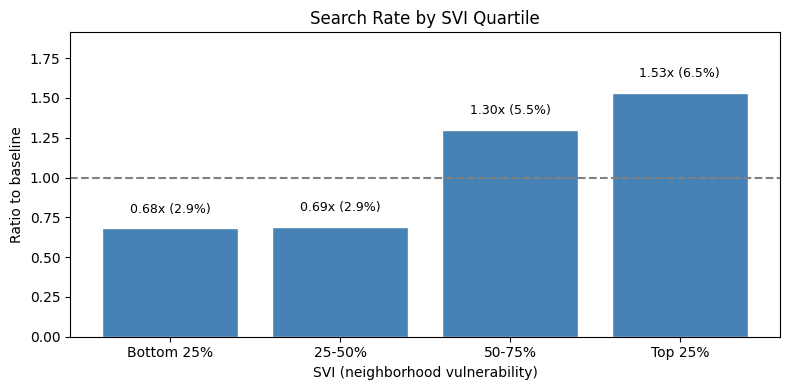

In [73]:
svi_labels = {"Q1 (low)": "Bottom 25%", "Q2": "25-50%", "Q3": "50-75%", "Q4 (high)": "Top 25%"}
svi_summary["x_label"] = svi_summary["svi_quartile"].astype(str).map(svi_labels)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(svi_summary["x_label"], svi_summary["ratio_to_baseline"], color="steelblue", edgecolor="white")
ax.axhline(1.0, color="gray", linestyle="--", label="Baseline (overall avg)")
ax.set_title("Search Rate by SVI Quartile")
ax.set_ylabel("Ratio to baseline")
ax.set_xlabel("SVI (neighborhood vulnerability)")
ymax = svi_summary["ratio_to_baseline"].max()
ax.set_ylim(top=ymax * 1.25)
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="none")
for bar, ratio, pct in zip(bars, svi_summary["ratio_to_baseline"], svi_summary["search_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f"{ratio:.2f}x ({pct:.1f}%)", ha="center", va="bottom", fontsize=9, bbox=bbox_props)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Analysis

The search rate increases steadily with neighborhood vulnerability. Stops in the most vulnerable quartile (Q4) are searched at roughly 2.3x the overall average, while stops in the least vulnerable quartile (Q1) fall well below the baseline. This suggests that neighborhood context plays a meaningful role in whether a search occurs.

### Deviation from mean

Each bar shows how many percentage points above or below the overall average each quartile falls. Coral bars are above average, blue bars are below.

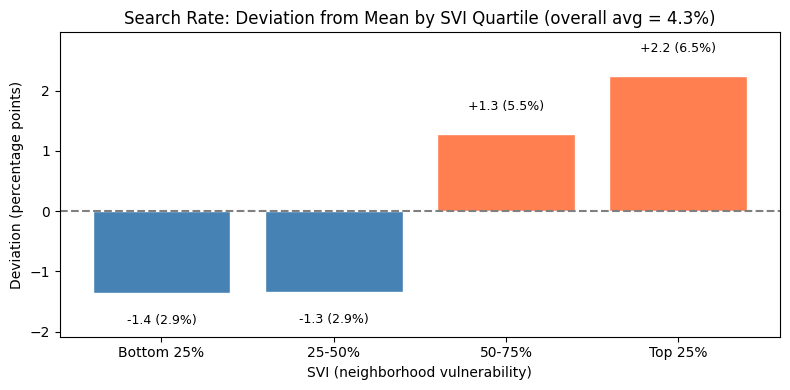

In [74]:
overall_rate_pct = overall_rate * 100
svi_summary["deviation_pp"] = svi_summary["search_rate_pct"] - overall_rate_pct

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("none")
ax.patch.set_facecolor("none")
vals = svi_summary["deviation_pp"]
colors = ["steelblue" if v < 0 else "coral" for v in vals]
bars = ax.bar(svi_summary["x_label"], vals, color=colors, edgecolor="white")
ax.axhline(0, color="gray", linestyle="--", label="Overall mean")
ax.set_title(f"Search Rate: Deviation from Mean by SVI Quartile (overall avg = {overall_rate_pct:.1f}%)")
ax.set_ylabel("Deviation (percentage points)")
ax.set_xlabel("SVI (neighborhood vulnerability)")
ax.margins(y=0.2)
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="none")
for bar, dev, pct in zip(bars, svi_summary["deviation_pp"], svi_summary["search_rate_pct"]):
    y = bar.get_height()
    va = "bottom" if y >= 0 else "top"
    offset = 0.35 if y >= 0 else -0.35
    ax.text(bar.get_x() + bar.get_width()/2, y + offset,
            f"{dev:+.1f} ({pct:.1f}%)", ha="center", va=va, fontsize=9, bbox=bbox_props)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Analysis

The deviation plot confirms a clear gradient. The bottom two SVI quartiles fall below the overall mean, while the top two are above it. The gap between Q1 and Q4 is several percentage points, which is substantial given the low base rate of searches overall.

## 4. Search Rate by Race across SVI Quartiles

Here we look at whether racial disparities in search rates hold across neighborhoods with different vulnerability levels. If the lines are roughly parallel, racial gaps persist regardless of neighborhood. If they converge or diverge, the relationship between race and search likelihood depends on where the stop happens.

In [75]:
race_summary = df.groupby("subject_race").agg(
    n=("search_conducted", "size"),
    search_rate=("search_conducted", lambda x: x.eq(True).mean())
).reset_index()
race_summary["search_rate_pct"] = (race_summary["search_rate"] * 100).round(2)
race_summary = race_summary.sort_values("search_rate", ascending=False)

print("Search rate by race:")
print(race_summary[["subject_race", "n", "search_rate_pct"]].to_string(index=False))

Search rate by race:
          subject_race      n  search_rate_pct
                 black  42705             9.07
              hispanic 117083             5.55
asian/pacific islander  32541             2.80
                 white 162226             2.78
                 other  27238             1.66


### Cross-tabulation: Race x SVI Quartile

The table below shows the search rate for each combination of race and SVI quartile, giving the raw numbers behind the line plot that follows.

In [76]:
top_races = tmp["subject_race"].value_counts().head(5).index.tolist()
tmp_race = tmp[tmp["subject_race"].isin(top_races)]
race_svi = tmp_race.groupby(["subject_race", "svi_quartile"], observed=False)["search_01"].mean().unstack()
race_svi_pct = (race_svi * 100).round(2)

print("Search rate (%) by Race x SVI quartile:")
print(race_svi_pct.to_string())

Search rate (%) by Race x SVI quartile:
svi_quartile            Q1 (low)    Q2    Q3  Q4 (high)
subject_race                                           
asian/pacific islander      1.99  1.56  4.67       5.58
black                       5.09  5.82  9.37      13.16
hispanic                    4.50  4.59  7.99       5.36
other                       1.27  1.42  1.85       3.49
white                       2.65  2.32  3.23       4.83


### Line plot

Each line represents a racial group. The x-axis moves from least vulnerable (Q1) to most vulnerable (Q4) neighborhoods. This reveals whether the racial gap in search rates widens, narrows, or stays constant as neighborhood vulnerability increases.

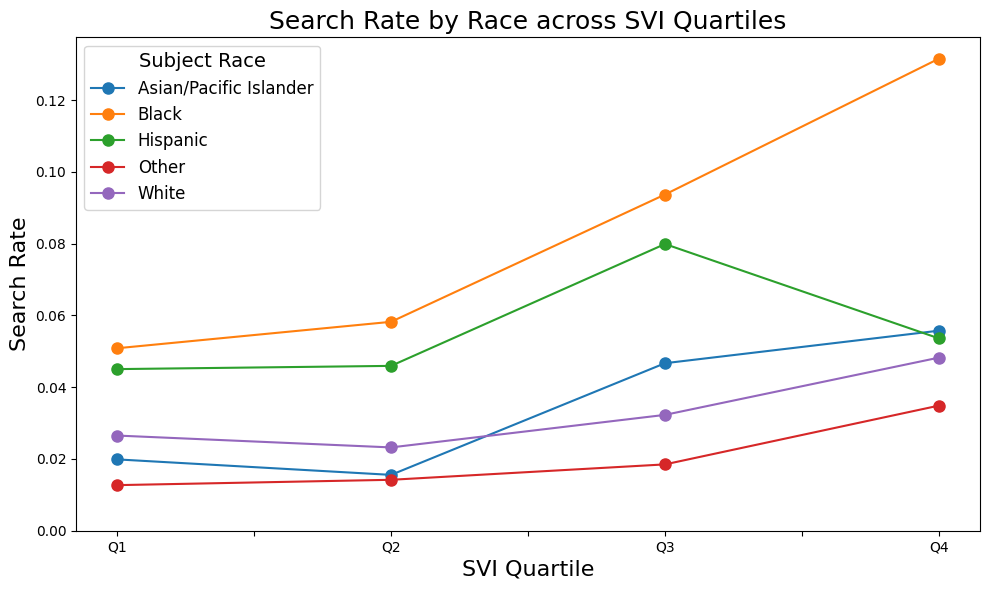

In [77]:
df_cc = df.dropna(subset=["svi_rpl_themes", "subject_race", "search_conducted"]).copy()
df_cc["svi_quartile"] = pd.qcut(df_cc["svi_rpl_themes"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
pivot_race_svi = df_cc.pivot_table(
    values="search_conducted",
    index="svi_quartile",
    columns="subject_race",
    aggfunc="mean",
    observed=False,
)
race_labels_line = {
    "asian/pacific islander": "Asian/Pacific Islander",
    "black": "Black",
    "hispanic": "Hispanic",
    "other": "Other",
    "white": "White",
}
pivot_race_svi = pivot_race_svi.rename(columns=race_labels_line)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("none")
ax.patch.set_facecolor("none")
pivot_race_svi.plot(ax=ax, marker="o", markersize=8)
ax.set_xlabel("SVI Quartile", fontsize=16)
ax.set_ylabel("Search Rate", fontsize=16)
ax.set_title("Search Rate by Race across SVI Quartiles", fontsize=18)
ax.tick_params(axis="both", labelsize=10)
ax.legend(title="Subject Race", loc="upper left", fontsize=12, title_fontsize=14)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

#### Analysis

Black subjects have the highest search rate in every SVI quartile, and the gap between Black and other racial groups tends to widen in more vulnerable neighborhoods. White and Asian/Pacific Islander subjects are searched at consistently lower rates. This indicates that racial disparities in search rates are not explained away by neighborhood vulnerability alone.

## 5. Search Rate by Reason for Stop

Not all stops carry the same likelihood of a search. A routine traffic violation rarely leads to a search, while a stop based on a dispatch call or suspect information is more targeted. We group the reasons into the six most common categories plus an "Other" bucket and compare search rates.

The table reports each reason category with total stops and search rate percentage.

In [78]:
K = 6
top_reasons = df["reason_for_stop"].value_counts(dropna=True).head(K).index.tolist()
reason_grp = df["reason_for_stop"].where(df["reason_for_stop"].isin(top_reasons), "Other")
reason_df = df.assign(reason_grp=reason_grp).dropna(subset=["reason_grp"])
reason_summary = reason_df.groupby("reason_grp").agg(
    n=("search_conducted", "size"),
    search_rate=("search_conducted", lambda x: x.eq(True).mean() * 100),
).reset_index()
reason_summary = reason_summary.sort_values("n", ascending=True).reset_index(drop=True)

reason_labels = {
    "Moving Violation": "Traffic violation (speeding, etc.)",
    "Equipment Violation": "Vehicle equipment (lights, registration)",
    "Radio Call/Citizen Contact": "Dispatch call or citizen report",
    "Muni, County, H&S Code": "Local or state law violation",
    "Personal Knowledge/Informant": "Officer's prior info or tip",
    "Suspect Info (I.S., Bulletin, Log)": "Wanted bulletin or suspect match",
    "No Cause Specified on a Card": "Reason not recorded",
    "Personal Observ/Knowledge": "Officer's direct observation",
    "Other": "Other",
}
reason_summary["reason_label"] = reason_summary["reason_grp"].map(
    lambda x: reason_labels.get(x, x)
)

reason_table = reason_summary[["reason_label", "n", "search_rate"]].copy()
reason_table = reason_table.sort_values("n", ascending=False).reset_index(drop=True)
reason_table["search_rate"] = reason_table["search_rate"].round(2)
reason_table = reason_table.rename(
    columns={
        "reason_label": "Reason for Stop",
        "n": "# of Stops",
        "search_rate": "Search Rate (%)",
    }
)

reason_table

,Reason for Stop,# of Stops,Search Rate (%)
0,"Traffic violation (speeding, etc.)",279839,2.63
1,"Vehicle equipment (lights, registration)",97372,8.04
2,Dispatch call or citizen report,1886,22.06
3,Local or state law violation,1291,16.50
4,Other,1253,7.02
5,Officer's prior info or tip,860,27.33
6,Wanted bulletin or suspect match,526,29.66


#### Analysis

The table highlights a tension between stop frequency and search likelihood. Moving and equipment violations account for most stops, yet their search rates are relatively low, consistent with routine enforcement encounters. By contrast, stops tied to dispatch or citizen reports, officer tips, or suspect bulletins are much less common but have substantially higher search rates. This suggests stop reason captures encounter context (routine vs. investigative) and is a strong situational predictor alongside race and SVI.

## 6. Service Area

**Service area summary:** Bar chart of stop counts by police service area (beat). Shows which areas have the most stops. The table also includes average SVI per area, linking geography to vulnerability.

In [79]:
svc_summary = df.groupby('service_area').agg(
    n=('raw_row_number', 'size'),
    svi_mean=('svi_rpl_themes', 'mean'),
    svi_missing=('svi_rpl_themes', lambda x: x.isna().sum())
).reset_index()
search_by_svc = df.groupby('service_area')['search_conducted'].apply(lambda x: x.eq(True).mean()).reset_index(name='search_rate')
svc_summary = svc_summary.merge(search_by_svc, on='service_area')

print("=== Top 10 service areas by stop count ===")
print(svc_summary.nlargest(10, 'n')[['service_area', 'n', 'svi_mean', 'search_rate']])

print("\n=== Service areas with missing SVI ===")
print(svc_summary[svc_summary['svi_missing'] > 0][['service_area', 'n', 'svi_missing']])

=== Top 10 service areas by stop count ===
   service_area      n  svi_mean  search_rate
5           310  31511  0.211233     0.023198
1           120  30838  0.143232     0.034276
10          520  29514  0.359256     0.030630
15          710  26824  0.672484     0.020765
4           240  25428  0.131157     0.024422
21          930  24797  0.075382     0.021978
0           110  24300  0.241848     0.031523
13          620  20951  0.347316     0.041382
3           230  19899  0.162551     0.019649
12          610  18999  0.121181     0.034949

=== Service areas with missing SVI ===
   service_area      n  svi_missing
2           130     90           90
14          630    201          201
20          840     28           28
22     Bulletin     26           26
23       County     42           42
24      Unknown  11240        11240


**Search rate and SVI by beat (map):** Beat boundaries (light gray) with **circle size ∝ search rate** and **color = mean SVI** (`svi_rpl_themes`) per service area (`serv`). Shows where high search rates overlap with more vulnerable neighborhoods beyond the aggregate bar chart above.

In [80]:
import geopandas as gpd

beats_map = gpd.read_file(RAW_DATA_PATH / "Police_Beats.geojson")
beats_map['beat'] = pd.to_numeric(beats_map['beat'], errors='coerce')
beats_map = beats_map[
    beats_map['beat'].notna() & (beats_map['beat'] > 0) & (beats_map['beat'] != 9)
].copy()

beats_proj = beats_map.to_crs('EPSG:32611')
beats_map['area_km2'] = beats_proj.geometry.area / 1e6
beats_map['centroid'] = beats_proj.geometry.centroid.to_crs(beats_map.crs)

_stops = df.dropna(subset=['serv', 'search_conducted']).copy()
_stops['serv'] = pd.to_numeric(_stops['serv'], errors='coerce')
_stops = _stops.dropna(subset=['serv'])
_stops['search_01'] = _stops['search_conducted'].astype(int)

zone_rates = (
    _stops.groupby('serv')
    .agg(search_rate=('search_01', 'mean'))
    .reset_index()
)

zone_svi = (
    df.dropna(subset=['serv', 'svi_rpl_themes'])
    .assign(serv=lambda d: pd.to_numeric(d['serv'], errors='coerce'))
    .dropna(subset=['serv'])
    .groupby('serv')
    .agg(svi_rpl_themes=('svi_rpl_themes', 'mean'))
    .reset_index()
)

beats_map['serv'] = pd.to_numeric(beats_map['serv'], errors='coerce')
beats_map = beats_map.merge(zone_rates, on='serv', how='left').merge(zone_svi, on='serv', how='left')

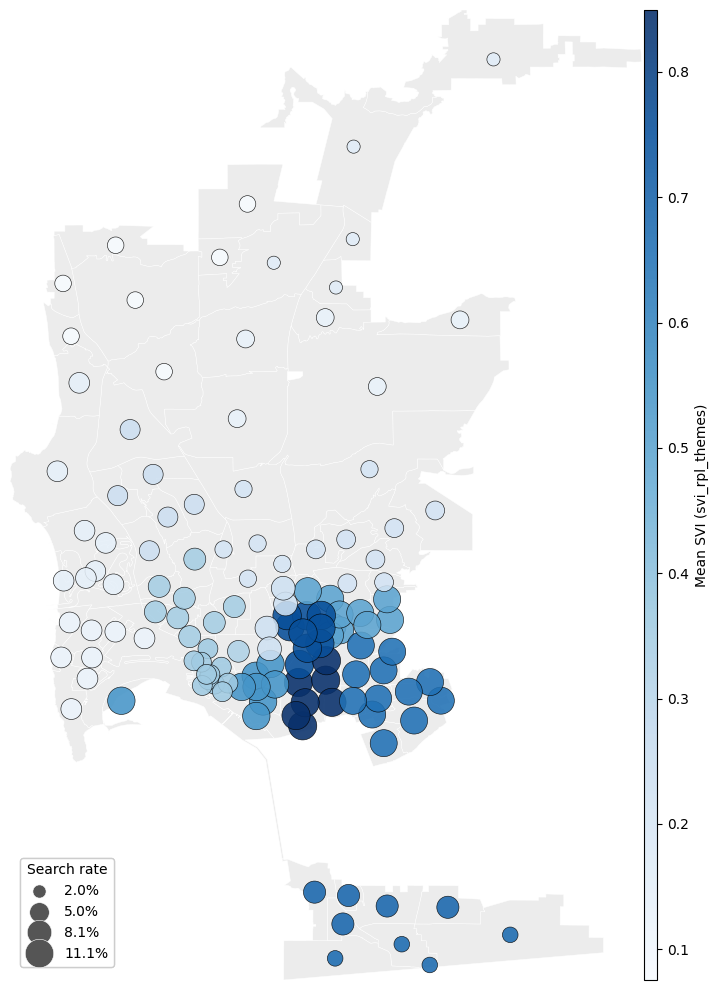

In [ ]:
import geopandas as gpd
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Build beat-level search-rate and mean-SVI summaries
zone_stats = (
    df.dropna(subset=["serv", "search_conducted", "svi_rpl_themes"])
    .assign(
        serv=lambda d: pd.to_numeric(d["serv"], errors="coerce"),
        search_01=lambda d: d["search_conducted"].astype(int),
    )
    .dropna(subset=["serv"])
    .groupby("serv", observed=False)
    .agg(
        search_rate=("search_01", "mean"),
        svi_rpl_themes=("svi_rpl_themes", "mean"),
    )
    .reset_index()
)

beats_map = gpd.read_file(RAW_DATA_PATH / "Police_Beats.geojson")
beats_map["serv"] = pd.to_numeric(beats_map["serv"], errors="coerce")
beats_map = beats_map.merge(zone_stats, on="serv", how="left")

# Drop tiny far-eastern sliver polygons (e.g. small offshore fragments) that only widen the map
_tmp = beats_map.to_crs("EPSG:32611")
_e = _tmp.geometry.centroid.x
beats_map = beats_map.loc[_e <= 505_000].copy()

# Reproject for centroids, then convert back for plotting
beats_proj = beats_map.to_crs("EPSG:32611")
beats_map["centroid"] = beats_proj.geometry.centroid.to_crs(beats_map.crs)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

beats_map.plot(
    ax=ax,
    color="#ececec",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.95,
)

plot_df = beats_map.dropna(subset=["centroid", "search_rate", "svi_rpl_themes"]).copy()
_cent = gpd.GeoSeries(plot_df["centroid"], crs=plot_df.crs)
cx = _cent.x.to_numpy()
cy = _cent.y.to_numpy()
sr = plot_df["search_rate"].to_numpy()
svi = plot_df["svi_rpl_themes"].to_numpy()

sr_min, sr_max = float(sr.min()), float(sr.max())
s_min_pts, s_max_pts = 90.0, 420.0
if sr_max > sr_min:
    t = np.sqrt((sr - sr_min) / (sr_max - sr_min))
    s_pts = s_min_pts + t * (s_max_pts - s_min_pts)
else:
    s_pts = np.full_like(sr, (s_min_pts + s_max_pts) / 2.0)

sc = ax.scatter(
    cx,
    cy,
    s=s_pts,
    c=svi,
    cmap="Blues",
    alpha=0.88,
    edgecolors="black",
    linewidths=0.45,
    zorder=3,
)

ax.set_axis_off()
ax.set_xlim(beats_map.total_bounds[0], beats_map.total_bounds[2])
ax.set_ylim(beats_map.total_bounds[1], beats_map.total_bounds[3])
ax.set_aspect("equal")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2.2%", pad=0.02)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("Mean SVI")

if sr_max > sr_min:
    tick_rates = np.linspace(sr_min, sr_max, num=4)
else:
    tick_rates = np.array([sr_min])

legend_sizes = []
legend_labels = []
for r in tick_rates:
    sp = s_min_pts + (r - sr_min) / (sr_max - sr_min + 1e-12) * (s_max_pts - s_min_pts)
    legend_sizes.append(np.sqrt(sp))
    legend_labels.append(f"{100 * r:.1f}%")

size_legend = ax.legend(
    [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="#555555",
            markeredgecolor="white",
            markeredgewidth=0.4,
            markersize=ms,
            linestyle="none",
        )
        for ms in legend_sizes
    ],
    legend_labels,
    title="Search rate",
    loc="lower left",
    bbox_to_anchor=(0.01, 0.01),
    borderaxespad=0.25,
    frameon=True,
    framealpha=0.92,
)
ax.add_artist(size_legend)

plt.tight_layout()
plt.show()

**Race × SVI quartile:** Heatmap or grouped bar of search rate by race and SVI quartile. Shows whether racial disparities in search rates vary by neighborhood vulnerability—e.g., whether Black subjects face higher search rates in both low- and high-SVI areas.

## 7. Key Relationships

**Numeric associations (Spearman):** Pairwise Spearman correlation among **subject age**, **SVI index** (`svi_rpl_themes`), and **hour of day** on the same complete-case rows as the categorical heatmap below.

**Categorical associations (Cramér's V):** Pairwise Cramér's V for nominal fields; \(V \in [0,1]\) with larger values indicating stronger association. With very large sample sizes, even modest \(V\) can correspond to significant \(\chi^2\) tests, so effect size is the main read here.

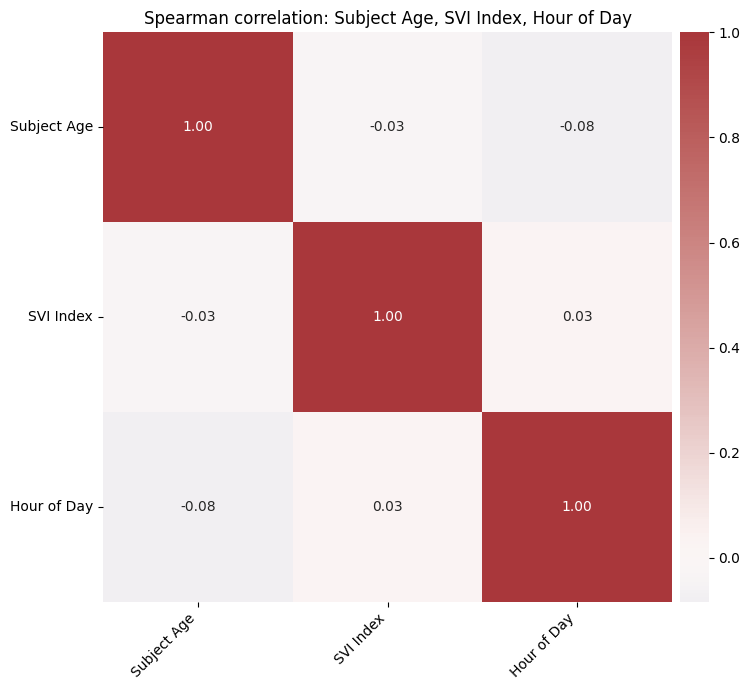

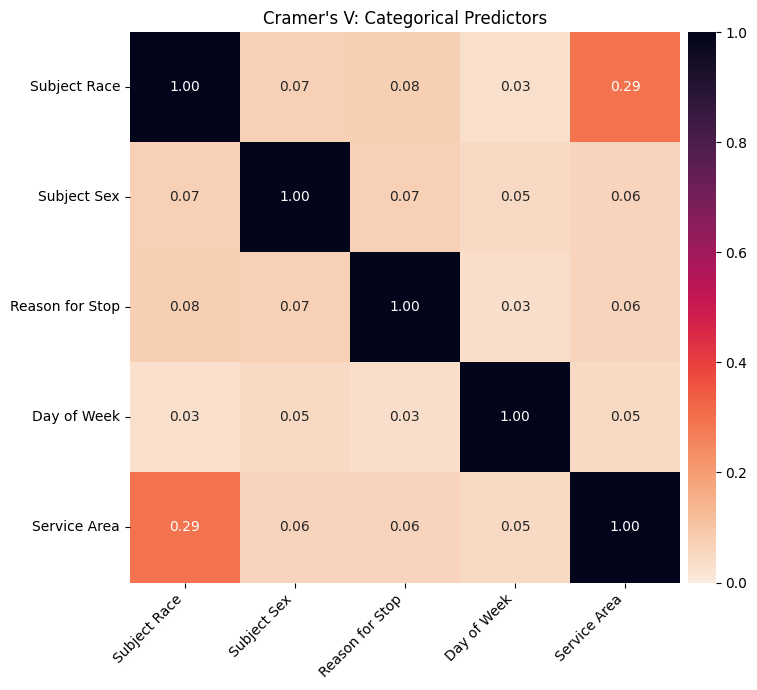

Complete-case rows used for heatmaps: 358690


In [82]:
import seaborn as sns
from scipy.stats import chi2_contingency

# Complete-case frame used for both heatmaps
corr_cols = [
    "subject_age", "svi_rpl_themes", "hour",
    "subject_race", "subject_sex", "reason_for_stop", "day_of_week", "service_area"
]
corr_cols = [c for c in corr_cols if c in df.columns]
df_corr = df.dropna(subset=corr_cols).copy()

# Pretty labels for plotting
pretty_labels = {
    "subject_race": "Subject Race",
    "subject_sex": "Subject Sex",
    "reason_for_stop": "Reason for Stop",
    "day_of_week": "Day of Week",
    "service_area": "Service Area",
    "svi_rpl_themes": "SVI Index",
    "subject_age": "Subject Age",
    "hour": "Hour of Day",
}

def relabel_index_columns(corr_df, mapping):
    corr_df = corr_df.copy()
    corr_df.index = [mapping.get(c, c) for c in corr_df.index]
    corr_df.columns = [mapping.get(c, c) for c in corr_df.columns]
    return corr_df

# ---- Spearman heatmap (numeric) ----
num_cols = [c for c in ["subject_age", "svi_rpl_themes", "hour"] if c in df_corr.columns]
num_corr = df_corr[num_cols].corr(method="spearman")
num_corr_pretty = relabel_index_columns(num_corr, pretty_labels)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

sns.heatmap(
    num_corr_pretty,
    cmap="vlag",
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    ax=ax,
    cbar_kws={"pad": 0.01},
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Spearman correlation: Subject Age, SVI Index, Hour of Day")
plt.tight_layout()
plt.show()

# ---- Cramer's V heatmap (categorical) ----
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.size == 0 or tab.shape[0] < 2 or tab.shape[1] < 2:
        return 0.0
    chi2, _, _, _ = chi2_contingency(tab, correction=False)
    n = tab.to_numpy().sum()
    if n == 0:
        return 0.0
    r, k = tab.shape
    denom = max(1, min(r - 1, k - 1))
    return float(np.sqrt((chi2 / n) / denom))

def cramers_v_matrix(frame, cols):
    cols = [c for c in cols if c in frame.columns]
    arr = np.eye(len(cols))
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = cramers_v(frame[cols[i]], frame[cols[j]])
            arr[i, j] = arr[j, i] = v
    return pd.DataFrame(arr, index=cols, columns=cols)

cat_cols = [
    "subject_race", "subject_sex", "reason_for_stop",
    "day_of_week", "service_area"
]
cat_cols = [c for c in cat_cols if c in df_corr.columns]

cat_corr = cramers_v_matrix(df_corr, cat_cols)
cat_corr_pretty = relabel_index_columns(cat_corr, pretty_labels)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

sns.heatmap(
    cat_corr_pretty,
    vmin=0,
    vmax=1,
    cmap="rocket_r",
    annot=True,
    fmt=".2f",
    square=True,
    ax=ax,
    cbar_kws={"pad": 0.01},
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Cramer's V: Categorical Predictors")
plt.tight_layout()
plt.show()

print("Complete-case rows used for heatmaps:", len(df_corr))